# House Price Prediction — Model Training & Evaluation

This notebook trains and evaluates multiple machine learning regression models
for predicting house sale prices.

## Objectives

- Load and prepare the Ames Housing dataset
- Split the data into training and validation sets
- Build preprocessing + model pipelines
- Train multiple regression models
- Generate predictions
- Evaluate models using MAE, RMSE, and R²
- Compare model performance
- Select a suitable baseline model

### Importing libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [4]:
PROJECT_ROOT=Path.cwd().parent
PROJECT_ROOT

WindowsPath('c:/Users/LENOVO/OneDrive/Desktop/Machine_Learning_Projects/house-price-prediction')

In [5]:
DATA_PATH=PROJECT_ROOT/ "data" / "train.csv"

df=pd.read_csv(DATA_PATH)

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
TARGET="SalePrice"

X=df.drop(columns=[TARGET])
y=df[TARGET]

print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (1460, 80)
y shape:  (1460,)


In [13]:
numerical_features=X.select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features=X.select_dtypes(include=['str']).columns.tolist()

print("Numerical features: ",len(numerical_features))
print("Categorical features: ",len(categorical_features))

Numerical features:  37
Categorical features:  43


In [14]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples: ",X_train.shape[0])
print("Validation samples: ",X_valid.shape[0])

Training samples:  1168
Validation samples:  292


In [15]:
numerical_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='median')),
        ("scaler",StandardScaler())
        ]
)

In [17]:
categorical_pipeline=Pipeline(
    steps= [
        ("imputer",SimpleImputer(strategy='most_frequent')),
        ("encoder",OneHotEncoder(handle_unknown='ignore'))
    ]   
)

In [19]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numerical_pipeline,numerical_features),
        ("cat",categorical_pipeline,categorical_features)
    ]
)

In [20]:
linear_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

In [21]:
linear_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [22]:
linear_predictions=linear_model.predict(X_valid)

linear_predictions[:10]

array([157721.84496363, 348809.83542607,  86344.50420131, 174030.86008128,
       316982.26279092,  66738.74305835, 235871.9079305 , 146338.44536735,
        57618.11663698, 154098.7737123 ])

In [23]:
def evaluate_model(model_name,y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)

    rmse=np.sqrt(mean_squared_error(y_true,y_pred))

    r2=r2_score(y_true,y_pred)


    return {
        "Model" : model_name,
        "MAE" : mae,
        "RMSE" : rmse,
        "R2" : r2 
    }

In [24]:
results=[]

linear_result=evaluate_model("Linear Regression",y_valid,linear_predictions)

results.append(linear_result)
pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Linear Regression,18284.712714,29476.15806,0.886727


In [25]:
ridge_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",Ridge(alpha=10.0))
        ]
)

In [26]:
ridge_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [36]:
ridge_predictions=ridge_model.predict(X_valid)
ridge_predictions[:10]

array([155982.3463706 , 336812.08953448,  98257.87434703, 177631.99876341,
       337769.00820603,  60575.13977595, 248480.75595455, 149191.02541538,
        55227.85278143, 151297.7461568 ])

In [37]:
ridge_result=evaluate_model(
    "Ridge Regression",
    y_valid,
    ridge_predictions
)

results.append(ridge_result)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Linear Regression,18284.712714,29476.158060,0.886727
1,Ridge Regression,19021.283722,30655.344441,0.877482


In [39]:
random_forest_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1))
    ]
)

In [40]:
random_forest_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [42]:
rf_predictions=random_forest_model.predict(X_valid)

In [43]:
rf_result=evaluate_model("Random Forest",y_valid,rf_predictions)

results.append(rf_result)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Linear Regression,18284.712714,29476.158060,0.886727
1,Ridge Regression,19021.283722,30655.344441,0.877482
2,Random Forest,17467.572158,28572.848758,0.893563


In [44]:
gradient_boosting_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,random_state=42,max_depth=3))
    ]
)

In [45]:
gradient_boosting_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [46]:
gb_predictions=gradient_boosting_model.predict(X_valid)

In [48]:
gb_result=evaluate_model("Gradient Boosting",y_valid,gb_predictions)

results.append(gb_result)

results_df=pd.DataFrame(results)

results_df



,Model,MAE,RMSE,R2
0,Linear Regression,18284.712714,29476.158060,0.886727
1,Ridge Regression,19021.283722,30655.344441,0.877482
2,Random Forest,17467.572158,28572.848758,0.893563
3,Gradient Boosting,16616.486134,27556.323776,0.901001


In [53]:
xgboost_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",XGBRegressor(n_estimators=300,learning_rate=0.05,random_state=42,max_depth=5))
        ]
)

In [54]:
xgboost_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [55]:
xgb_predictions=xgboost_model.predict(X_valid)

In [56]:
xgb_result=evaluate_model("XGBoost Regression",y_valid,xgb_predictions)


results.append(xgb_result)

results_df=pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,18284.712714,29476.158060,0.886727
1,Ridge Regression,19021.283722,30655.344441,0.877482
2,Random Forest,17467.572158,28572.848758,0.893563
3,Gradient Boosting,16616.486134,27556.323776,0.901001
4,XGBoost Regression,15820.934570,25074.478499,0.918031


In [57]:
results_df.sort_values(by='RMSE',ascending=True)

,Model,MAE,RMSE,R2
4,XGBoost Regression,15820.934570,25074.478499,0.918031
3,Gradient Boosting,16616.486134,27556.323776,0.901001
2,Random Forest,17467.572158,28572.848758,0.893563
0,Linear Regression,18284.712714,29476.158060,0.886727
1,Ridge Regression,19021.283722,30655.344441,0.877482


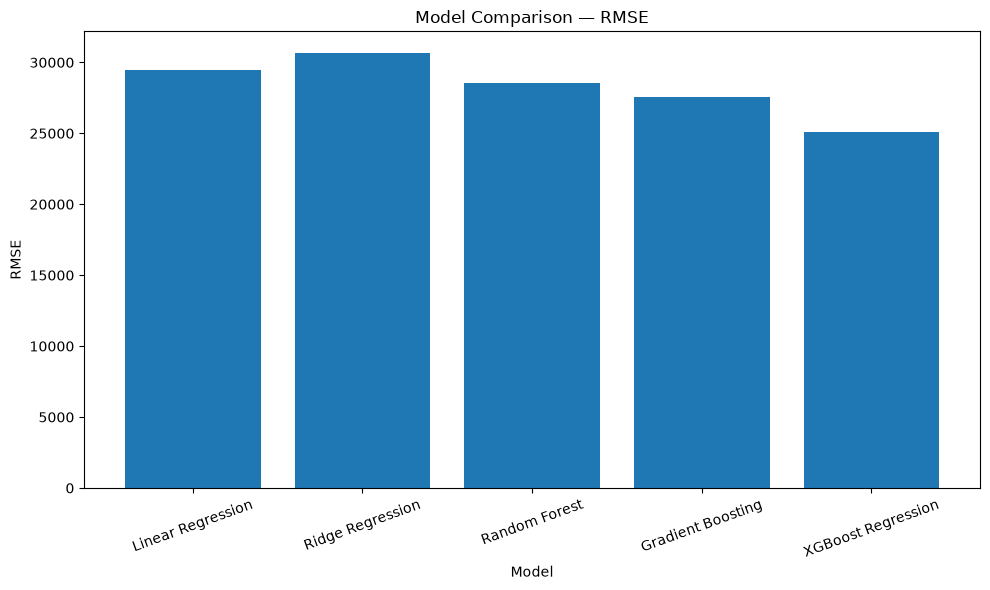

In [59]:
plt.figure(figsize=(10,6))

plt.bar(results_df["Model"],results_df["RMSE"])

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [61]:
best_model_name=results_df.loc[results_df["RMSE"].idxmin(),"Model"]

best_model_name

'XGBoost Regression'

In [63]:
prediction_map={
    "Linear Regression" : linear_predictions,
    "Ridge Regression" : ridge_predictions,
    "Random Forest" : rf_predictions,
    "Gradient Boosting" : gb_predictions,
    "XGBoost Regression" : xgb_predictions
}

best_predictions=prediction_map[best_model_name]
best_predictions

array([139185.31 , 346842.4  , 114184.734, 165725.23 , 322492.94 ,
        80755.55 , 227714.38 , 147667.44 ,  84903.72 , 135243.05 ,
       146897.95 , 121163.44 , 115481.79 , 203632.94 , 170423.48 ,
       135514.9  , 195127.77 , 137779.6  , 115551.88 , 202448.66 ,
       148418.27 , 236856.7  , 172222.95 , 132387.86 , 196537.05 ,
       170545.6  , 195599.95 , 103732.8  , 171621.   , 183177.23 ,
       126585.586, 251252.03 , 177617.08 , 117409.63 , 248627.48 ,
       146149.95 , 114219.56 , 207795.62 , 315505.03 , 121748.91 ,
       129490.984, 232316.86 , 117962.09 , 377981.6  , 127341.03 ,
       137547.7  , 114784.74 , 125458.4  , 428398.6  , 139847.3  ,
       125146.15 , 197324.34 , 112647.47 , 318686.25 , 145497.8  ,
       255486.12 , 195824.62 , 156328.31 , 136444.84 ,  99291.13 ,
        74653.555, 161454.23 , 315361.12 , 277710.22 , 256546.39 ,
       229994.22 , 113974.95 , 336628.88 , 117408.38 , 166326.08 ,
       126506.38 , 127250.21 , 115189.94 ,  85610.61 , 472370.

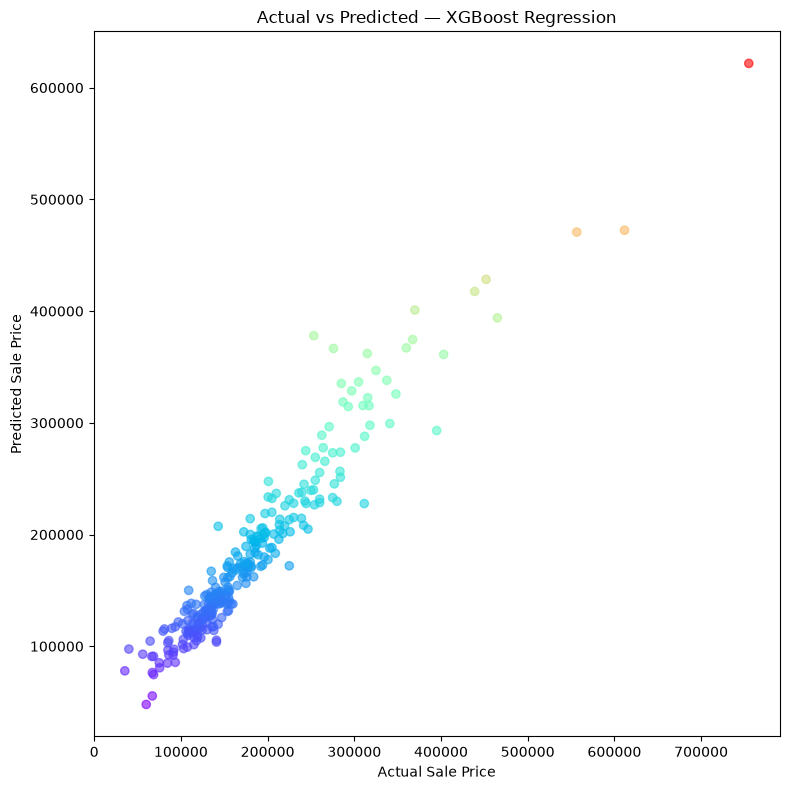

In [68]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_valid,
    best_predictions,
    c=best_predictions,
    cmap='rainbow',
    alpha=0.6
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.tight_layout()
plt.show()

In [75]:
errors=y_valid-best_predictions

error_df=pd.DataFrame({"Actual": y_valid,
                      "Predicted":best_predictions,
                      "Error":errors})

error_df.head(10)

,Actual,Predicted,Error
892,154500,139185.312500,15314.687500
1105,325000,346842.406250,-21842.406250
413,115000,114184.734375,815.265625
522,159000,165725.234375,-6725.234375
1036,315500,322492.937500,-6992.937500
614,75500,80755.546875,-5255.546875
218,311500,227714.375000,83785.625000
1160,146000,147667.437500,-1667.437500
649,84500,84903.718750,-403.718750
887,135500,135243.046875,256.953125


In [76]:
error_df["Absolute_Error"]=(error_df["Error"].abs())

error_df.sort_values(by="Absolute_Error",ascending=False).head(10)

,Actual,Predicted,Error,Absolute_Error
898,611657,472370.375000,139286.625000,139286.625000
691,755000,621723.750000,133276.250000,133276.250000
581,253293,377981.593750,-124688.593750,124688.593750
774,395000,293085.000000,101915.000000,101915.000000
261,276000,366540.781250,-90540.781250,90540.781250
1046,556581,470747.906250,85833.093750,85833.093750
218,311500,227714.375000,83785.625000,83785.625000
1243,465000,393981.875000,71018.125000,71018.125000
588,143000,207375.796875,-64375.796875,64375.796875
30,40000,97501.109375,-57501.109375,57501.109375
